# Fig: Infotaxis, mismatch agentLower scenario: pmax_th=0.95

Reference: 
- `20251230_fig_mismatch_agent_truth_efficiency_comparison.ipynb`
- `20260515_fig_mismatch_agent_truth_efficiency_comparison_agentHigher_pmax0.95.ipynb`

In [1]:
from pathlib import Path

import pandas as pd

import seaborn as sns

In [2]:
from plot_utils import bar_violinplot_success
from simulation_data_prep import get_success_fname

In [3]:
# Set path
path_data = Path("/Volumes/ssd_2tb_1/infotaxis_simu_2026")

path_fig = Path("../figs_paper_2026")

Samples: left:  989    right:  926
Mean:    left: 10.498  right: 10.686
Median:  left: 10.000  right: 10.000

MWU test
 - different: 0.58288
 - less:      0.29144
 - greater:   0.70859
--------------------------------------------
Samples: left:  989    right:  832
Mean:    left: 10.498  right: 11.019
Median:  left: 10.000  right: 10.000

MWU test
 - different: 0.08518
 - less:      0.04259
 - greater:   0.95742
--------------------------------------------
Samples: left:  989    right:  618
Mean:    left: 10.498  right: 10.909
Median:  left: 10.000  right: 10.000

MWU test
 - different: 0.82699
 - less:      0.41350
 - greater:   0.58655
--------------------------------------------
Samples: left:  989    right:  245
Mean:    left: 10.498  right: 8.886
Median:  left: 10.000  right: 7.000

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------


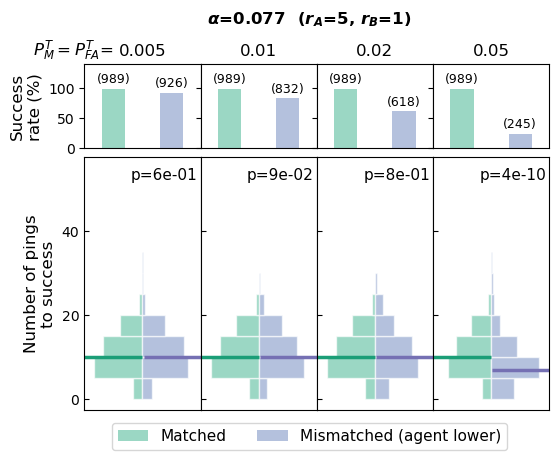

Samples: left:  977    right:  890
Mean:    left: 7.558  right: 7.976
Median:  left: 7.000  right: 8.000

MWU test
 - different: 0.00082
 - less:      0.00041
 - greater:   0.99959
--------------------------------------------
Samples: left:  977    right:  738
Mean:    left: 7.558  right: 8.289
Median:  left: 7.000  right: 8.000

MWU test
 - different: 0.00008
 - less:      0.00004
 - greater:   0.99996
--------------------------------------------
Samples: left:  977    right:  460
Mean:    left: 7.558  right: 8.248
Median:  left: 7.000  right: 8.000

MWU test
 - different: 0.00810
 - less:      0.00405
 - greater:   0.99595
--------------------------------------------
Samples: left:  977    right:  109
Mean:    left: 7.558  right: 6.697
Median:  left: 7.000  right: 6.000

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------


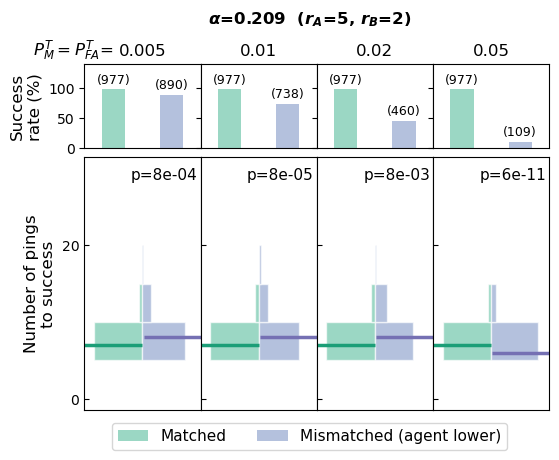

Samples: left:  986    right:  886
Mean:    left: 29.492  right: 28.893
Median:  left: 28.000  right: 26.500

MWU test
 - different: 0.32605
 - less:      0.83700
 - greater:   0.16302
--------------------------------------------
Samples: left:  986    right:  707
Mean:    left: 29.492  right: 29.253
Median:  left: 28.000  right: 27.000

MWU test
 - different: 0.39810
 - less:      0.80098
 - greater:   0.19905
--------------------------------------------
Samples: left:  986    right:  344
Mean:    left: 29.492  right: 24.535
Median:  left: 28.000  right: 21.000

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------
Samples: left:  986    right:   91
Mean:    left: 29.492  right: 11.286
Median:  left: 28.000  right: 9.000

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------


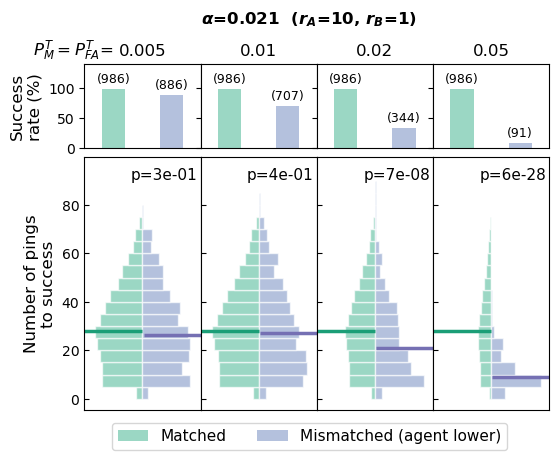

Samples: left:  980    right:  862
Mean:    left: 15.112  right: 16.151
Median:  left: 14.000  right: 15.000

MWU test
 - different: 0.00757
 - less:      0.00378
 - greater:   0.99622
--------------------------------------------
Samples: left:  980    right:  620
Mean:    left: 15.112  right: 16.834
Median:  left: 14.000  right: 16.000

MWU test
 - different: 0.00370
 - less:      0.00185
 - greater:   0.99815
--------------------------------------------
Samples: left:  980    right:  265
Mean:    left: 15.112  right: 13.781
Median:  left: 14.000  right: 11.000

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------
Samples: left:  980    right:   33
Mean:    left: 15.112  right: 8.455
Median:  left: 14.000  right: 8.000

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------


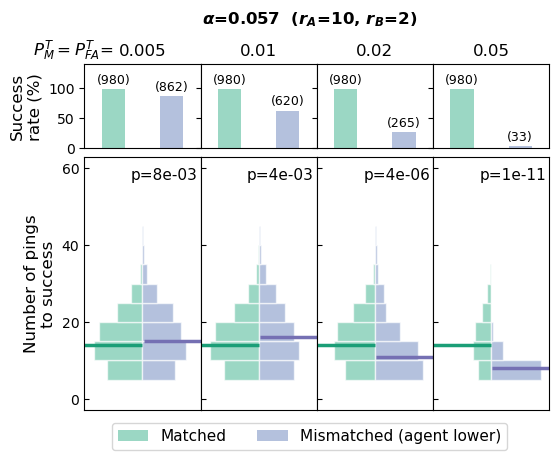

In [4]:
cr_all = [5, 10]
br_all = [1, 2]
pm_truth_all = [0.005, 0.01, 0.02, 0.05]
pm_agent_all = [0.001] * len(pm_truth_all)

for cr in cr_all:
    for br in br_all:

        path_left = path_data / "20260530_infotaxis_match_summary_compiled_pmax095_pmaxDiff1e-5"
        path_right = path_data / "20260530_infotaxis_mismatch_agentLower_summary_compiled_pmax095_pmaxDiff1e-5"
        pmax_th = 0.95
        pmax_diff_th = 1e-5

        df_x_all = []
        df_y_all = []
        for idx, (pm_agent, pm_truth) in enumerate(zip(pm_agent_all, pm_truth_all)):
            # Load summary and ph details
            df_x = pd.read_csv(
                path_left / get_success_fname(
                    search_type="infotaxis", cr=cr, br=br, simulation_type="simple",
                    pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
                    pm_agent=pm_agent
                ), index_col=0
            )
            df_y = pd.read_csv(
                path_right / get_success_fname(
                    search_type="infotaxis", cr=cr, br=br, simulation_type="mismatch",
                    pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
                    pm_agent=pm_agent, pm_truth=pm_truth
                ), index_col=0
            )
            df_x_all.append(df_x)
            df_y_all.append(df_y)

        fig = bar_violinplot_success(
            cr=cr, br=br, pm_all=pm_truth_all,
            df_x_all=df_x_all, df_y_all=df_y_all,
            x_str="Matched", y_str="Mismatched (agent lower)",
            stats_type="two-sided",
            colors=sns.color_palette("Set2"),
            colors_dark=sns.color_palette("Dark2"),
            color_idx_left=0, color_idx_right=2,
            print_stats=True,
            comparison_type="agent_lower",
        )

        fig.savefig(
            path_fig / f"fig_mismatch_agentLower_cr{cr}_br{br}_pmaxTh0.95_pmaxDiff1e-5_infotaxis.png",
            dpi=300, bbox_inches="tight"
        )